In [7]:
import torch as py 

In [8]:
from torchvision import datasets

In [9]:
from torchvision import transforms


In [10]:
from torch.utils.data import DataLoader
from torch.utils.data import Subset


In [ ]:
import torchvision
import random 


In [ ]:
from torchvision.models._api import WeightsEnum


In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import cv2



In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

In [16]:
from torchvision import models
device = py.device("mps" if py.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [17]:
import torch.nn as nn


In [19]:
import torch.optim as optim


In [20]:

import torch
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
from PIL import Image

from sklearn.metrics import classification_report
from torch.nn import functional as F

In [21]:
#from torchvision.models._api import WeightsEnum
#from torchvision.models._api import _IMAGENET_CATEGORIES

In [22]:
#import sys
#!{sys.executable} -m pip install matplotlib

In [23]:
import matplotlib.pyplot as plt

In [24]:
import sys
!{sys.executable} -m pip install pandas

In [25]:
import pandas as pd
import numpy as np

In [26]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
   


In [27]:
from torch.utils.data import Dataset, DataLoader
from facenet_pytorch import MTCNN, InceptionResnetV1
from torchvision import transforms
from PIL import Image
import os
import torch

class DeepfakeFaceDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []

        self.classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for file in os.listdir(class_dir):
                if file.endswith(('.jpg', '.png')):
                    self.image_paths.append(os.path.join(class_dir, file))
                    self.labels.append(label_idx)


        self.mtcnn = MTCNN(image_size=224, margin=20)
        self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert("RGB")

        face = self.mtcnn(img)
        if face is None:
            return torch.zeros(3, 224, 224), -1  # return dummy image if no face
        return face, label


In [28]:
 #dataset = datasets.ImageFolder("/Users/amrutavelamuri/Downloads/Dataset/Train", transform=data_transforms['train'])

dataset = DeepfakeFaceDataset("/Users/amrutavelamuri/Downloads/GitHubDataset/Train")

#dataset = DeepfakeFaceDataset("/Users/amrutavelamuri/Downloads/Dataset/Train")

#dataset = datasets.ImageFolder("/Users/amrutavelamuri/Downloads/Reseach3", transform=data_transforms['Train'])
for epoch in range(10):
    # Randomly sample 50,000 images from the full 140k each epoch
    subset_size = min(2000, len(dataset))
    subset_indices = random.sample(range(len(dataset)), subset_size)

    small_dataset = Subset(dataset, subset_indices)
    dataloader = DataLoader(small_dataset, batch_size=5, shuffle=True, num_workers=0)


In [31]:

import matplotlib.pyplot as plt 


In [32]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)


In [33]:
dataloader=DataLoader(    
    dataset,batch_size=20,shuffle=True,num_workers=0)


for batch_idx, (images, labels) in enumerate(dataloader):
    if batch_idx == 5:  # After 5 batches, stop (you can adjust the number)
        break
    print(f"Batch {batch_idx + 1} labels: {labels.tolist()}")

Batch 1 labels: [0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0]
Batch 2 labels: [1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1]
Batch 3 labels: [0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1]
Batch 4 labels: [1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1]
Batch 5 labels: [0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1]


In [34]:
print(f"Total images loaded: {len(dataset)}")


Total images loaded: 2000


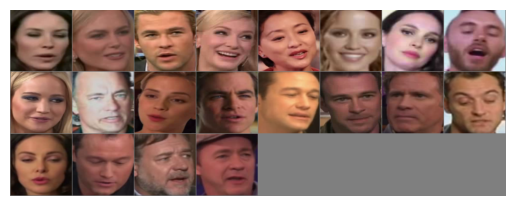

Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes
Label Index: 0 | Class Name: real
Label Index: 0 | Class Name: real
Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes
Label Index: 1 | Class Name: fakes
Label Index: 0 | Class Name: real
Label Index: 0 | Class Name: real
Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes
Label Index: 0 | Class Name: real
Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes
Label Index: 1 | Class Name: fakes
Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes
Label Index: 1 | Class Name: fakes
Label Index: 0 | Class Name: real
Label Index: 1 | Class Name: fakes


In [35]:

def imshow(img):
    img = img.cpu() * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()
for batch_idx, (images, labels) in enumerate(dataloader):
    if batch_idx == 1:  
        random_indices = random.sample(range(images.size(0)), 20)
        selected_images = images[random_indices]
        selected_labels = labels[random_indices]

        imshow(torchvision.utils.make_grid(selected_images))

        for idx in range(20):
            label_index = selected_labels[idx].item()
            class_name = dataset.classes[label_index]
            print(f"Label Index: {label_index} | Class Name: {class_name}")
        break


In [36]:
dataiter=iter(dataloader
             
             )
images,lables=next(dataiter)

In [37]:






'''train_data1=imshow(torchvision.utils.make_grid(images[:10]))
for idx in range(10): 
    path, label = dataset.samples[idx]
    class_name = dataset.classes[label]
    print(f"Image Path: {path} | Label: {label} ({class_name})")
    '''

'train_data1=imshow(torchvision.utils.make_grid(images[:10]))\nfor idx in range(10): \n    path, label = dataset.samples[idx]\n    class_name = dataset.classes[label]\n    print(f"Image Path: {path} | Label: {label} ({class_name})")\n    '

In [38]:

print(dataset.classes)

['real', 'fakes']


In [39]:
torchvision.models.resnet50

<function torchvision.models.resnet.resnet50(*, weights: Union[torchvision.models.resnet.ResNet50_Weights, NoneType] = None, progress: bool = True, **kwargs: Any) -> torchvision.models.resnet.ResNet>

In [40]:
from torchvision.models import resnet50, ResNet50_Weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)

In [41]:
'''
class MulticlassLogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MulticlassLogisticRegression, self).__init__()
        self.linear = nn.Linear(3 * 256 * 256, 2
    def forward(self, x):
        x = x.view(x.size(0), -1) 
        out = self.linear(x)
        if self.linear is None:
            self.linear = nn.Linear(x.shape[1], self.output_dim)
        return out'''


class SimpleCNN(nn.Module):
    def __init__(self, output_dim):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 226, 226)
            x = self.pool1(F.relu(self.conv1(dummy_input)))
            x = self.pool2(F.relu(self.conv2(x)))
            self.flattened_size = x.view(1, -1).shape[1]
        print(x.shape)
        self.fc1 = nn.Linear(100352, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

In [42]:
model = SimpleCNN(output_dim=10)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_losses = []
train_accuracies = []

for epoch in range(2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:  # Use your training DataLoader here
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(dataloader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")


torch.Size([1, 32, 56, 56])
Epoch 1: Train Loss=0.7801, Train Acc=0.5790
Epoch 2: Train Loss=0.6239, Train Acc=0.6665


In [43]:
for inputs, labels in dataloader:
    print(labels)  
    break

tensor([1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1])


In [46]:
correct = 0
total = 0
with torch.no_grad():
    for data in dataloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 69.25%


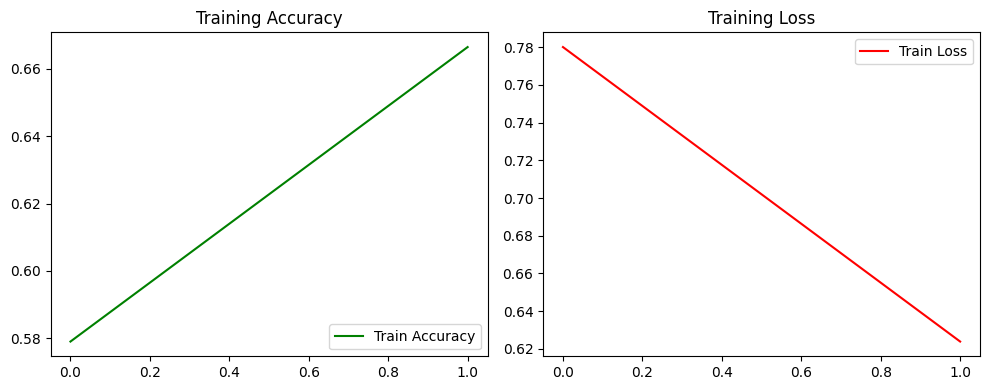